# ABSA Perfume Reviews — Two-Stage Fine-Tuning Pipeline

**Goal:** Given a raw perfume review, predict which aspects are discussed
(Aroma, Packaging, Longevity, Value for Money, Projection, or none) and the
sentiment (positive / negative / neutral) for each detected aspect.

**Approach:** Two independently fine-tuned models sharing the same pretrained
Indonesian RoBERTa encoder (`w11wo/indonesian-roberta-base-sentiment-classifier`):

- **Model A (Aspect Detection):** multi-label classifier — review text in,
  set of aspects out (empty set = "No Aspect").
- **Model B (Sentiment Classification):** aspect-aware classifier — review
  text + one aspect in, sentiment out.

**Pipeline flow:** `new review -> Model A -> if no aspect: stop -> else: Model B per aspect`


# 0. Setup & Configuration

## 0.1 Install & Imports
**Objective:** get all dependencies loaded before touching any data.

In [ ]:
!pip install -q transformers datasets scikit-learn matplotlib seaborn

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, hamming_loss
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding
)
from datasets import Dataset

import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

pd.set_option('display.max_colwidth', None)

## 0.2 Global Configuration
**Objective:** one place to control every knob (paths, model checkpoint, seed,
label names) - nothing below this cell should contain a hardcoded "magic string".

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/data/processed/perfume_review_flattened.csv"
MODEL_CHECKPOINT = "w11wo/indonesian-roberta-base-sentiment-classifier"
NO_ASPECT_LABEL = "No Aspect"
MAX_LEN = 256
SAVE_DIR = "/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/output/models"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# 1. Data Loading & Exploration

## 1.1 Load Raw Annotated Data
**Objective:** load the flattened LLM-annotated CSV (one row per review-aspect pair)
and do a first sanity check on shape and columns.

In [ ]:
df = pd.read_csv(DATA_PATH)
df['aspect'] = df['aspect'].astype(str).str.strip()
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Unique reviews:", df['review_id'].nunique())
df.head()

Shape: (8086, 4)
Columns: ['review_id', 'review_text', 'aspect', 'sentiment']
Unique reviews: 5578


,review_id,review_text,aspect,sentiment
0,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Aroma,positive
1,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Packaging,positive
2,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Aroma,positive
3,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Longevity,positive
4,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Packaging,positive


## 1.2 Class Distribution
**Objective:** quantify imbalance *before* modeling - this determines whether
we need class weighting, focal loss, or a stratified split later.

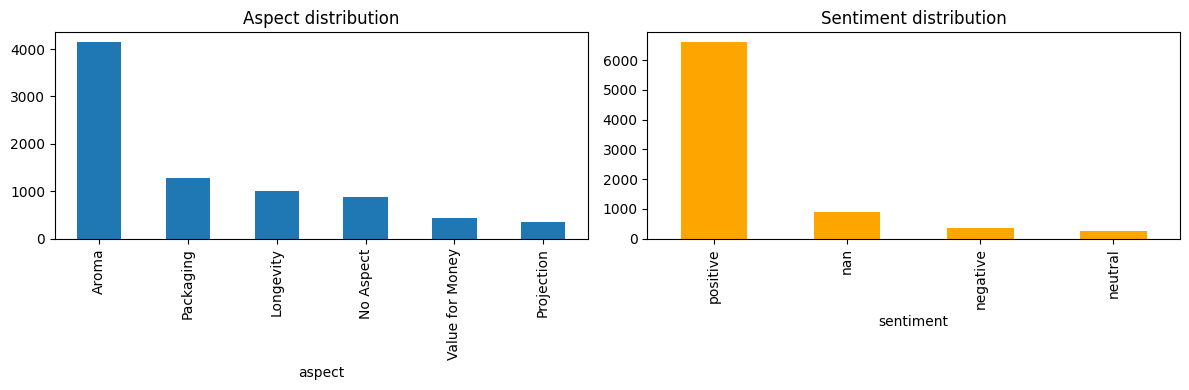

aspect
Aroma              4145
Packaging          1287
Longevity          1002
No Aspect           880
Value for Money     432
Projection          340
Name: count, dtype: int64

sentiment
positive    6604
nan          880
negative     355
neutral      247
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['aspect'].value_counts().plot(kind='bar', ax=axes[0], title='Aspect distribution')
df['sentiment'].value_counts().plot(kind='bar', ax=axes[1], title='Sentiment distribution', color='orange')

plt.tight_layout()
plt.show()

print(df['aspect'].value_counts())
print()
print(df['sentiment'].value_counts())

In [ ]:
ASPECT_LIST = sorted(a for a in df['aspect'].unique() if a.lower() != NO_ASPECT_LABEL.lower())
print("Detected aspect classes:", ASPECT_LIST)
assert len(ASPECT_LIST) == 5, f"Expected 5 aspects, got {len(ASPECT_LIST)}"

Detected aspect classes: ['Aroma', 'Longevity', 'Packaging', 'Projection', 'Value for Money']


# 2. Data Preparation

## 2.1 Build Aspect Detection Dataset
**Objective:** collapse the flattened rows back to **one row per review**,
with a multi-label vector of which aspects are present. A review with zero
real-aspect rows naturally gets an all-zero label vector - this *is* how
"No Aspect" is represented, no separate class needed.

In [ ]:
def build_aspect_df(df):
    grouped = (
        df[df['aspect'].str.lower() != NO_ASPECT_LABEL.lower()]
        .groupby('review_id')['aspect']
        .apply(lambda x: sorted(set(x)))
        .reset_index()
        .rename(columns={'aspect': 'aspects'})
    )

    text_map = df.drop_duplicates('review_id').set_index('review_id')['review_text']

    all_reviews = df[['review_id']].drop_duplicates()
    out = all_reviews.merge(grouped, on='review_id', how='left')
    out['aspects'] = out['aspects'].apply(lambda x: x if isinstance(x, list) else [])
    out['review_text'] = out['review_id'].map(text_map)
    return out

aspect_df = build_aspect_df(df)

mlb = MultiLabelBinarizer(classes=ASPECT_LIST)
label_matrix = mlb.fit_transform(aspect_df['aspects'])
ASPECT_COLS = list(mlb.classes_)

for i, col in enumerate(ASPECT_COLS):
    aspect_df[col] = label_matrix[:, i]

print("Reviews with no aspect (all-zero label):", (label_matrix.sum(axis=1) == 0).sum())
print("Total reviews:", len(aspect_df))
aspect_df.head()

Reviews with no aspect (all-zero label): 880
Total reviews: 5578


,review_id,aspects,review_text,Aroma,Longevity,Packaging,Projection,Value for Money
0,RVW_00001,"[Aroma, Packaging]","Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",1,0,1,0,0
1,RVW_00002,"[Aroma, Longevity, Packaging]",Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,1,1,1,0,0
2,RVW_00003,"[Packaging, Value for Money]","produk sesuai deskripsi, produk berkualitas, harga bersaing, pengemasan baik, pengiriman baik",0,0,1,0,1
3,RVW_00004,"[Aroma, Value for Money]","pengiriman aman dan cepat, belanja dapet harga oke dan pastinya di jamin ori berawal dari nyobain bodymist nya dan suka banget aroma segarnya yang ringan dan nyari tau untuk produk parfum dan langsung pesan ternyata aroma nya beda tipis tipis aja untuk ketahanan belom cobain",1,0,0,0,1
4,RVW_00005,"[Aroma, Packaging]","packing aman banget, wangi ny bener2 se enakk itu, apa lagi pas udh dry done nya🥹🥹🥹, the besttt pwwollllll",1,0,1,0,0


## 2.2 Build Sentiment Dataset
**Objective:** keep only real aspect rows (drop "No Aspect" rows - sentiment
classification only makes sense once an aspect is confirmed present), and
encode sentiment labels to integer ids.

In [ ]:
sentiment_df = df[df['aspect'].str.lower() != NO_ASPECT_LABEL.lower()].copy()

SENTIMENT_LABELS = sorted(sentiment_df['sentiment'].unique())
sent2id = {s: i for i, s in enumerate(SENTIMENT_LABELS)}
id2sent = {i: s for s, i in sent2id.items()}

sentiment_df['label'] = sentiment_df['sentiment'].map(sent2id)

print("Sentiment classes:", SENTIMENT_LABELS)
sentiment_df[['review_id', 'review_text', 'aspect', 'sentiment', 'label']].head()

Sentiment classes: ['negative', 'neutral', 'positive']


,review_id,review_text,aspect,sentiment,label
0,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Aroma,positive,2
1,RVW_00001,"Wanginya pas buat saya..elegant, ringan, seger..box kemasannya keren, botolnya juga simple elwgant, keren..gak nyangka aja ownernya alumni ITB..😄",Packaging,positive,2
2,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Aroma,positive,2
3,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Longevity,positive,2
4,RVW_00002,Fix ini parfum hmns terbaik terenak terdebes. Bagi penyuka Citrus sih bakal SUKA BGTTTT. Tapi klo ga gitu suka wangi jejerukan bakal gasuka wkwk. Ketahanannya bisa 6 jam di baju duh cinta. Packagingnya juga gemes bgt. Makasih ya udh nyiptain iniii,Packaging,positive,2


## 2.3 Train / Validation / Test Split
**Objective:** split by `review_id` (not by row) so the same review never
leaks across splits - a review with 2 aspect rows must stay entirely in one
split. Both task datasets reuse the *same* review-id split, keeping them
comparable.

In [ ]:
def group_split(ids, test_size, seed=SEED):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(gss.split(ids, groups=ids))
    return set(ids[idx_a]), set(ids[idx_b])

all_ids = aspect_df['review_id'].values
train_ids, temp_ids = group_split(all_ids, test_size=0.2)
val_ids, test_ids = group_split(np.array(list(temp_ids)), test_size=0.5)

def split_by_ids(data, ids):
    return data[data['review_id'].isin(ids)].reset_index(drop=True)

aspect_train, aspect_val, aspect_test = (
    split_by_ids(aspect_df, train_ids),
    split_by_ids(aspect_df, val_ids),
    split_by_ids(aspect_df, test_ids),
)
sentiment_train, sentiment_val, sentiment_test = (
    split_by_ids(sentiment_df, train_ids),
    split_by_ids(sentiment_df, val_ids),
    split_by_ids(sentiment_df, test_ids),
)

print(f"Reviews  -> train={len(train_ids)}  val={len(val_ids)}  test={len(test_ids)}")
print(f"Aspect rows    -> train={len(aspect_train)}  val={len(aspect_val)}  test={len(aspect_test)}")
print(f"Sentiment rows -> train={len(sentiment_train)}  val={len(sentiment_val)}  test={len(sentiment_test)}")

Reviews  -> train=4462  val=558  test=558
Aspect rows    -> train=4462  val=558  test=558
Sentiment rows -> train=5771  val=727  test=708


## 2.4 Verify Split Distribution
**Objective:** with negative (355) and neutral (247) being rare overall,
confirm val/test actually contain enough examples of each class to produce
a *stable* F1 estimate - not just check that the split ran without error.

In [ ]:
for name, split_df in [("train", sentiment_train), ("val", sentiment_val), ("test", sentiment_test)]:
    print(f"\n{name} sentiment distribution:")
    print(split_df['sentiment'].value_counts())

for name, split_df in [("train", aspect_train), ("val", aspect_val), ("test", aspect_test)]:
    print(f"\n{name} aspect counts:")
    print(split_df[ASPECT_COLS].sum())


train sentiment distribution:
sentiment
positive    5315
negative     271
neutral      185
Name: count, dtype: int64

val sentiment distribution:
sentiment
positive    658
negative     40
neutral      29
Name: count, dtype: int64

test sentiment distribution:
sentiment
positive    631
negative     44
neutral      33
Name: count, dtype: int64

train aspect counts:
Aroma              3318
Longevity           798
Packaging          1040
Projection          265
Value for Money     346
dtype: int64

val aspect counts:
Aroma              409
Longevity           98
Packaging          127
Projection          36
Value for Money     56
dtype: int64

test aspect counts:
Aroma              413
Longevity          106
Packaging          120
Projection          39
Value for Money     30
dtype: int64


# 3. Tokenization

## 3.1 Load Tokenizer
**Objective:** load once, reuse for both tasks - both models share the same
vocabulary since they share the same base checkpoint.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 3.2 Tokenize Aspect Dataset
**Objective:** single-sequence tokenization (just the review text) since
aspect detection doesn't need any auxiliary input.

In [ ]:
def to_hf_dataset_aspect(pdf):
    ds = Dataset.from_pandas(pdf[['review_text'] + ASPECT_COLS])
    ds = ds.map(lambda x: {'labels': [float(x[c]) for c in ASPECT_COLS]})
    ds = ds.map(lambda b: tokenizer(b['review_text'], truncation=True, max_length=MAX_LEN), batched=True)
    ds = ds.remove_columns(['review_text'] + ASPECT_COLS)
    ds.set_format('torch')
    return ds

aspect_train_ds = to_hf_dataset_aspect(aspect_train)
aspect_val_ds   = to_hf_dataset_aspect(aspect_val)
aspect_test_ds  = to_hf_dataset_aspect(aspect_test)

Map:   0%|          | 0/4462 [00:00<?, ? examples/s]

Map:   0%|          | 0/4462 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

Map:   0%|          | 0/558 [00:00<?, ? examples/s]

## 3.3 Tokenize Sentiment Dataset
**Objective:** sentence-pair tokenization (`review_text`, `aspect`) - this is
what lets one shared encoder produce a different prediction per aspect for
the same review, via the `[SEP]`-separated aspect token as context.

In [ ]:
def to_hf_dataset_sentiment(pdf):
    ds = Dataset.from_pandas(pdf[['review_text', 'aspect', 'label']])
    ds = ds.map(
        lambda b: tokenizer(b['review_text'], b['aspect'], truncation=True, max_length=MAX_LEN),
        batched=True
    )
    ds = ds.remove_columns(['review_text', 'aspect'])
    ds.set_format('torch')
    return ds

sentiment_train_ds = to_hf_dataset_sentiment(sentiment_train)
sentiment_val_ds   = to_hf_dataset_sentiment(sentiment_val)
sentiment_test_ds  = to_hf_dataset_sentiment(sentiment_test)

Map:   0%|          | 0/5771 [00:00<?, ? examples/s]

Map:   0%|          | 0/727 [00:00<?, ? examples/s]

Map:   0%|          | 0/708 [00:00<?, ? examples/s]

# 4. Class Imbalance Handling

## 4.1 Sentiment Class Weights
**Objective:** compensate for positive (~92%) dominating negative (~5%) and
neutral (~3%) - without this, the model can hit high accuracy while
never learning to recognize negative/neutral reviews. Weights are clipped
to avoid instability from the ~19-27x raw ratio.

In [ ]:
class_weights_raw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(SENTIMENT_LABELS)),
    y=sentiment_train['label'].values
)
class_weights = torch.tensor(class_weights_raw, dtype=torch.float).clamp(max=8.0).to(DEVICE)
print(dict(zip(SENTIMENT_LABELS, class_weights.tolist())))

{'negative': 7.098401069641113, 'neutral': 8.0, 'positive': 0.3619316518306732}


## 4.2 Aspect Pos-Weights
**Objective:** same idea for multi-label aspect detection - rare aspects
(Projection, Value for Money) get up-weighted in `BCEWithLogitsLoss` so the
model doesn't just learn to always predict the dominant aspect (Aroma).

In [ ]:
pos_counts = aspect_train[ASPECT_COLS].sum(axis=0).values
neg_counts = len(aspect_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.clip(pos_counts, 1, None), dtype=torch.float)
pos_weight = pos_weight.clamp(max=10.0).to(DEVICE)
print(dict(zip(ASPECT_COLS, pos_weight.tolist())))

{'Aroma': 0.34478601813316345, 'Longevity': 4.5914788246154785, 'Packaging': 3.290384531021118, 'Projection': 10.0, 'Value for Money': 10.0}


# 5. Model A - Aspect Detection (Multi-Label)

## 5.1 Model & Custom Trainer
**Objective:** load the pretrained encoder with a fresh multi-label head
(`ignore_mismatched_sizes=True` discards the original 3-class sentiment head),
and use a custom `Trainer` so we can inject the weighted BCE loss from Section 4.2.

In [ ]:
aspect_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(ASPECT_COLS),
    problem_type="multi_label_classification",
    ignore_mismatched_sizes=True
).to(DEVICE)

class WeightedBCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, labels.float())
        return (loss, outputs) if return_outputs else loss

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                        | Status   |                                                                                       
---------------------------+----------+---------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([5, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([5])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## 5.2 Metrics
**Objective:** track F1-micro/macro, Hamming loss, and exact-match accuracy -
macro F1 is the primary model-selection metric since it weighs rare aspects
(Projection) equally with common ones (Aroma).

In [ ]:
def compute_metrics_aspect(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {
        "f1_micro": f1_score(labels, preds, average='micro', zero_division=0),
        "f1_macro": f1_score(labels, preds, average='macro', zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
        "exact_match": accuracy_score(labels, preds),
    }

## 5.3 Training
**Objective:** fine-tune with early stopping on validation `f1_macro` -
`load_best_model_at_end=True` keeps the best epoch's weights, not necessarily
the last epoch's (protects against late-stage overfitting).

In [ ]:
aspect_args = TrainingArguments(
    output_dir="./checkpoints/aspect_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

aspect_trainer = WeightedBCETrainer(
    model=aspect_model,
    args=aspect_args,
    train_dataset=aspect_train_ds,
    eval_dataset=aspect_val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_aspect,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

aspect_trainer.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Hamming Loss,Exact Match,Runtime,Samples Per Second,Steps Per Second
1,0.403114,0.430664,0.849372,0.780895,0.077419,0.668459,4.046800,137.888000,4.448000
2,0.240948,0.324680,0.900000,0.836337,0.053763,0.749104,3.717000,150.121000,4.843000
3,0.178253,0.389447,0.913943,0.858276,0.046237,0.790323,3.692600,151.112000,4.875000
4,0.097844,0.408407,0.912925,0.859922,0.045878,0.790323,3.655500,152.647000,4.924000
5,0.065901,0.445659,0.922554,0.865325,0.040860,0.808244,3.697500,150.914000,4.868000
6,0.062896,0.450921,0.920678,0.866710,0.041935,0.802867,3.668000,152.127000,4.907000
7,0.034824,0.501712,0.918771,0.848652,0.042652,0.802867,3.648300,152.948000,4.934000
8,0.025027,0.495623,0.921918,0.861906,0.040860,0.810036,3.684800,151.432000,4.885000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2232, training_loss=0.1698970430961219, metrics={'train_runtime': 800.127, 'train_samples_per_second': 44.613, 'train_steps_per_second': 2.79, 'total_flos': 1617119992362768.0, 'train_loss': 0.1698970430961219, 'epoch': 8.0})

## 5.4 Test Evaluation
**Objective:** final, unbiased check on data never used for training or
model selection - this number is what actually goes in the portfolio report.

In [ ]:
aspect_test_out = aspect_trainer.predict(aspect_test_ds)
aspect_test_probs = 1 / (1 + np.exp(-aspect_test_out.predictions))
aspect_test_preds = (aspect_test_probs >= 0.5).astype(int)
aspect_test_labels = aspect_test_out.label_ids

print(classification_report(aspect_test_labels, aspect_test_preds, target_names=ASPECT_COLS, zero_division=0))
print("Exact match accuracy:", accuracy_score(aspect_test_labels, aspect_test_preds))
print("Hamming loss:", hamming_loss(aspect_test_labels, aspect_test_preds))

                 precision    recall  f1-score   support

          Aroma       0.97      0.95      0.96       413
      Longevity       0.88      0.98      0.93       106
      Packaging       0.90      0.96      0.93       120
     Projection       0.72      0.67      0.69        39
Value for Money       0.79      0.73      0.76        30

      micro avg       0.92      0.93      0.93       708
      macro avg       0.85      0.86      0.85       708
   weighted avg       0.92      0.93      0.93       708
    samples avg       0.78      0.78      0.77       708

Exact match accuracy: 0.8279569892473119
Hamming loss: 0.03763440860215054


**Observation**

The aspect detection model achieved a micro F1-score of 0.93, indicating excellent overall performance in identifying aspect labels across the dataset. The macro F1-score of 0.85 suggests that while the model performs consistently well on common aspects such as Aroma, Longevity, and Packaging, performance is lower for minority aspects such as Projection and Value for Money. This performance gap is expected given the class imbalance, although the use of pos_weight helped mitigate its impact.

# 6. Model B - Aspect-Aware Sentiment Classification

## 6.1 Model & Custom Trainer
**Objective:** same pattern as Model A, swapped for single-label
classification with weighted cross-entropy (Section 4.1).

In [ ]:
sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(SENTIMENT_LABELS),
    ignore_mismatched_sizes=True
).to(DEVICE)

class WeightedCETrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = nn.CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 6.2 Metrics
**Objective:** accuracy alone is misleading given ~92% positive skew - track
F1-macro (equal weight per class) as the primary selection metric, alongside
weighted F1 for a "realistic distribution" reference point.

In [ ]:
def compute_metrics_sentiment(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average='macro'),
        "f1_weighted": f1_score(labels, preds, average='weighted'),
    }

## 6.3 Training

In [ ]:
sentiment_args = TrainingArguments(
    output_dir="./checkpoints/sentiment_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

sentiment_trainer = WeightedCETrainer(
    model=sentiment_model,
    args=sentiment_args,
    train_dataset=sentiment_train_ds,
    eval_dataset=sentiment_val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_sentiment,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

sentiment_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.916921,0.818889,0.891334,0.607512,0.898185
2,0.844184,1.007837,0.913343,0.598571,0.909316
3,0.770498,1.161996,0.902338,0.617496,0.907440
4,0.680519,1.190453,0.935351,0.681730,0.931645
5,0.542443,1.643068,0.938102,0.697969,0.932333
6,0.163205,1.673816,0.932600,0.681365,0.930312
7,0.060922,1.794099,0.936726,0.709059,0.933871
8,0.034660,1.767659,0.936726,0.709659,0.933976


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2888, training_loss=0.4593502738799415, metrics={'train_runtime': 1124.1233, 'train_samples_per_second': 41.07, 'train_steps_per_second': 2.569, 'total_flos': 2547270372632958.0, 'train_loss': 0.4593502738799415, 'epoch': 8.0})

## 6.4 Test Evaluation

              precision    recall  f1-score   support

    negative       0.78      0.73      0.75        44
     neutral       0.39      0.27      0.32        33
    positive       0.96      0.98      0.97       631

    accuracy                           0.93       708
   macro avg       0.71      0.66      0.68       708
weighted avg       0.92      0.93      0.92       708



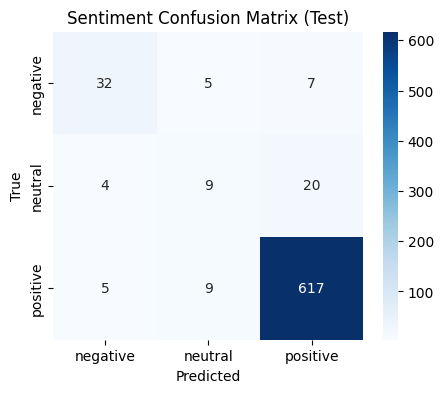

In [ ]:
sentiment_test_out = sentiment_trainer.predict(sentiment_test_ds)
sentiment_test_preds = np.argmax(sentiment_test_out.predictions, axis=1)
sentiment_test_labels = sentiment_test_out.label_ids

print(classification_report(sentiment_test_labels, sentiment_test_preds, target_names=SENTIMENT_LABELS))

cm = confusion_matrix(sentiment_test_labels, sentiment_test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Sentiment Confusion Matrix (Test)')
plt.show()

Observation

# 7. Error Analysis

## 7.1 Sentiment Errors
**Objective:** find *where* Model B fails - which aspects have the most
misclassifications, and read actual examples to spot patterns (sarcasm,
mixed clauses, slang not seen in training).

In [ ]:
sent_err_df = sentiment_test.reset_index(drop=True).copy()
sent_err_df['pred_label'] = sentiment_test_preds
sent_err_df['pred_sentiment'] = sent_err_df['pred_label'].map(id2sent)
sent_err_df['correct'] = sent_err_df['label'] == sent_err_df['pred_label']

errors = sent_err_df[~sent_err_df['correct']]
print(f"Total sentiment errors: {len(errors)} / {len(sent_err_df)}")
print("\nErrors per aspect:")
print(errors['aspect'].value_counts())

errors[['review_text', 'aspect', 'sentiment', 'pred_sentiment']].sample(min(15, len(errors)))

Total sentiment errors: 50 / 708

Errors per aspect:
aspect
Aroma              25
Longevity           9
Projection          8
Packaging           6
Value for Money     2
Name: count, dtype: int64


,review_text,aspect,sentiment,pred_sentiment
153,"aman dikulit, ada bau kayak bunga mungkin melati. overall seger sih baunya. cocok untuk berpergian outdoor maupun indoor. wadahnya ternyata plastik yah, packagingnya bagus banget dan ternyata gede lho 250ml tuh. dan ga terlalu nusuk baunya. tapi bagi yang ga suka wangi, ini akan nusuk dan pusing baunya.. terimakasih HMNS kak tsana dan team",Aroma,neutral,positive
519,"kalo awal2 agak strong, kalo dah brp jam di pakek baru terasa soft tex",Aroma,positive,neutral
401,"Nice, wangi manisnya enakk tp ketahanan belum yg awaw ya",Longevity,negative,neutral
672,Parfum nya enak tapi jatuhnya kayak permen alpelible,Aroma,neutral,positive
193,"repurchase karena memang seenak itu wanginya, warm floral dan manis, enak banget dan wanginya juga tahan kurang lebih 5 jam an, kalau udah agak lama memang harus di sniff dulu baru kecium, tapi emang seenak ituu, thanks",Projection,negative,positive
688,"packaging nya rapi bgt... dri aromanya wangi sii,, tpii ternyata ga terlalu cocok untuk akunya, mgkn untuk org yg suka aroma yg fresh cocok bgt.. tpii overall untuk aroma nya wangi",Aroma,positive,negative
325,"blind buy sebenernya untuk dipake olahraga, agak bimbang juga antara solaris atau saff.. well, solaris ini cocok buat cowok apalagi dipake olahraga. wanginya gak nyengak atau too strong, but soft. dan kena keringet engga yg bikin nambah bau. untuk keawetan bisa 2-3 jam aja. packaging oke banget dan dapet bonus trial varian lain juga. thanks seller.",Longevity,negative,positive
309,"baru kali ini nemu toko service pengirimannya bagus banget. dan pas banget pertama kali dpt harga fs juga, worth banget. emang lebih ke cewek wanginya, akhirnya aku jual😭",Aroma,neutral,positive
429,"Udah langganan beli.. selalu suka dengan aromanya, tahan lama dan lembut. Cuma harganya weowe drpd yg aroma laen. Sooo selalu nunggu kalau ada diskon",Value for Money,negative,positive
239,"packing rapi, pengiriman cepat walau lg tanggal merah natalan 🫰 untuk performa hmns mah ga perlu diragukan lagi, tp buat yg ngincar SPL prefer ke farhampton aja si. sengaja ngoleksi hmns krn secinta itu 🌹🌹🌹🌹🌹",Projection,negative,positive


## 7.2 Aspect Errors
**Objective:** same idea for Model A - per-aspect false positive/negative
counts, plus reviews where the *entire predicted aspect set* mismatches the
true set.

In [ ]:
for i, col in enumerate(ASPECT_COLS):
    fp = ((aspect_test_labels[:, i] == 0) & (aspect_test_preds[:, i] == 1)).sum()
    fn = ((aspect_test_labels[:, i] == 1) & (aspect_test_preds[:, i] == 0)).sum()
    print(f"{col}: FP={fp}, FN={fn}")

asp_err_df = aspect_test.reset_index(drop=True).copy()
mismatch_idx = np.where((aspect_test_labels != aspect_test_preds).any(axis=1))[0]
print(f"\nReviews with at least one aspect mismatch: {len(mismatch_idx)} / {len(asp_err_df)}")
asp_err_df.loc[mismatch_idx, ['review_text'] + ASPECT_COLS].sample(min(10, len(mismatch_idx)))

Aroma: FP=14, FN=20
Longevity: FP=14, FN=2
Packaging: FP=13, FN=5
Projection: FP=10, FN=13
Value for Money: FP=6, FN=8

Reviews with at least one aspect mismatch: 96 / 558


,review_text,Aroma,Longevity,Packaging,Projection,Value for Money
427,"bagus banget, pakai ini berasa fresh seharian dan enak bangettt",1,0,0,0,0
73,Sempurna ...... Makasih bonus botol kecil nya,0,0,0,0,0
445,"Kualitas produk: BAGUS, WANGI SABUN, ADA TEH TEHNYA DIKIT. WORTH IT BANGET BUAT DIBELI Tapi minusnya yang tinggal di Bekasi harus nunggu 1-4 hari baru terkirim Overall 10/10",1,0,0,0,1
443,"Product quality: after 3 kali beli yg 50ml, akhirnya beli yg 100ml sekalian. sesuka itu sama wanginya, best purchase",1,0,0,0,1
434,"Sesuka itu sama parfum ini, wanginya lembut dan ampuh mengusir bau tidak sedap pada badan. bikin aku pede seharian..",1,0,0,0,0
133,pengiriman aman dan cepat aromanya segar soft perpaduan yang menyegarkan untuk ketahanan belum tau karena baru pertama kali beli dan coba barang ori,1,0,0,0,0
336,Product quality: awetttt smwaa cuma yg troupe ga blind buy friendly yaa,1,1,0,0,0
428,"barang bagus, sampai dengan selamat. di lapisi bubble wrap tebal, wangi floralnya kecium banget, jdnya notes lain kurang kecium, awal awal bau alkohol banget, ga nyangka baunya lebih ke fresh floral bukan floral manis, buat cowo lumayan lah",1,0,0,0,0
375,Kualitas produk: Wangi. Tapi belum dicoba awet enggak nya cuma suka wanginya,1,0,0,0,0
471,"Seperti biasa, gak usah diraguin lagi Monroeeee Awal2nya masih bau alkohol, tapi pas diemin semalaman, langsung keluar wangi aslinyaaaa",1,0,0,0,0


## 7.3 Mixed-Polarity Review Check
**Objective:** specifically test the model on reviews where different
aspects genuinely have different sentiments (e.g. Aroma positive, Packaging
negative). This is the hardest case for an aspect-aware model relying on
attention rather than explicit clause segmentation - isolate it to see if
it needs special handling.

In [ ]:
review_sentiment_variety = sentiment_df.groupby('review_id')['sentiment'].nunique()
mixed_review_ids = review_sentiment_variety[review_sentiment_variety > 1].index

mixed_test = sent_err_df[sent_err_df['review_id'].isin(mixed_review_ids)]
single_test = sent_err_df[~sent_err_df['review_id'].isin(mixed_review_ids)]

print(f"Mixed-polarity test rows: {len(mixed_test)}  |  accuracy: {mixed_test['correct'].mean():.3f}")
print(f"Single-polarity test rows: {len(single_test)}  |  accuracy: {single_test['correct'].mean():.3f}")

Mixed-polarity test rows: 112  |  accuracy: 0.768
Single-polarity test rows: 596  |  accuracy: 0.960


# 8. Save Best Models
**Objective:** persist both fine-tuned models plus the label mappings needed
to interpret their outputs later, in one self-contained folder.

In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)

aspect_trainer.save_model(os.path.join(SAVE_DIR, "aspect_model"))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, "aspect_model"))

sentiment_trainer.save_model(os.path.join(SAVE_DIR, "sentiment_model"))
tokenizer.save_pretrained(os.path.join(SAVE_DIR, "sentiment_model"))

with open(os.path.join(SAVE_DIR, "label_mappings.json"), "w") as f:
    json.dump({
        "aspect_labels": ASPECT_COLS,
        "sentiment_labels": SENTIMENT_LABELS,
        "sent2id": sent2id,
        "id2sent": id2sent,
        "no_aspect_label": NO_ASPECT_LABEL,
    }, f, indent=2, ensure_ascii=False)

print("Saved to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/output/models


In [ ]:
import os

print(os.path.abspath(SAVE_DIR))

/content/drive/MyDrive/PORTFOLIO #4 - ABSA Perfume/output/models


# 9. Inference Pipeline

## 9.1 Load Saved Models
**Objective:** reload from disk (not from the in-memory trainer objects) to
confirm the saved artifacts actually work standalone - this is what your
production/deployment code would do.

In [ ]:
aspect_tok = AutoTokenizer.from_pretrained(os.path.join(SAVE_DIR, "aspect_model"))
aspect_mdl = AutoModelForSequenceClassification.from_pretrained(os.path.join(SAVE_DIR, "aspect_model")).to(DEVICE).eval()

sent_tok = AutoTokenizer.from_pretrained(os.path.join(SAVE_DIR, "sentiment_model"))
sent_mdl = AutoModelForSequenceClassification.from_pretrained(os.path.join(SAVE_DIR, "sentiment_model")).to(DEVICE).eval()

with open(os.path.join(SAVE_DIR, "label_mappings.json")) as f:
    mappings = json.load(f)

ASPECT_LABELS = mappings['aspect_labels']
ID2SENT = {int(k): v for k, v in mappings['id2sent'].items()}

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

## 9.2 End-to-End Predict Function
**Objective:** implement the exact business flow: `review -> aspect model ->
stop if none -> sentiment model per detected aspect`.

In [ ]:
import torch.nn.functional as F

def predict_absa(review_text, aspect_threshold=0.5):
    # Stage 1: aspect detection
    inputs = aspect_tok(review_text, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        logits = aspect_mdl(**inputs).logits
    probs = torch.sigmoid(logits).cpu().numpy()[0]

    detected_aspects = [
        (ASPECT_LABELS[i], float(probs[i]))
        for i, p in enumerate(probs) if p >= aspect_threshold
    ]

    if not detected_aspects:
        # tetap tunjukin confidence tertinggi walau di bawah threshold, buat debugging
        top_idx = int(np.argmax(probs))
        return {
            "review_text": review_text,
            "aspects": [],
            "note": "No Aspect - stop",
            "closest_aspect_below_threshold": {
                "aspect": ASPECT_LABELS[top_idx],
                "confidence": float(probs[top_idx])
            }
        }

    # Stage 2: aspect-wise sentiment
    results = []
    for aspect, aspect_conf in detected_aspects:
        s_inputs = sent_tok(review_text, aspect, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            s_logits = sent_mdl(**s_inputs).logits
        s_probs = F.softmax(s_logits, dim=1).cpu().numpy()[0]
        pred_id = int(np.argmax(s_probs))

        results.append({
            "aspect": aspect,
            "aspect_confidence": round(aspect_conf, 4),
            "sentiment": ID2SENT[pred_id],
            "sentiment_confidence": round(float(s_probs[pred_id]), 4)
        })

    return {"review_text": review_text, "aspects": results}

## 9.3 Test on Sample Review
**Objective:** sanity-check the whole pipeline end-to-end on a hand-written
mixed-polarity example before running it on the full dataset.

In [ ]:
predict_absa("Wanginya enak banget tapi packagingnya agak lecet pas nyampe")

{'review_text': 'Wanginya enak banget tapi packagingnya agak lecet pas nyampe',
 'aspects': [{'aspect': 'Aroma',
   'aspect_confidence': 0.9713,
   'sentiment': 'positive',
   'sentiment_confidence': 0.9997},
  {'aspect': 'Packaging',
   'aspect_confidence': 0.9954,
   'sentiment': 'negative',
   'sentiment_confidence': 0.9992}]}

In [ ]:
predict_absa("Baunya emang caramel cokelat gitu. Bagus sih. Jd kek deket kue. Tp yg ini longevity-nya kurang banget.")

{'review_text': 'Baunya emang caramel cokelat gitu. Bagus sih. Jd kek deket kue. Tp yg ini longevity-nya kurang banget.',
 'aspects': [{'aspect': 'Aroma',
   'aspect_confidence': 0.8762,
   'sentiment': 'positive',
   'sentiment_confidence': 0.9995},
  {'aspect': 'Longevity',
   'aspect_confidence': 0.9973,
   'sentiment': 'negative',
   'sentiment_confidence': 0.9984}]}

In [ ]:
predict_absa("Wanginya enak, tapi ketahanannya kurang.")

{'review_text': 'Wanginya enak, tapi ketahanannya kurang.',
 'aspects': [{'aspect': 'Aroma',
   'aspect_confidence': 0.9831,
   'sentiment': 'positive',
   'sentiment_confidence': 0.9996},
  {'aspect': 'Longevity',
   'aspect_confidence': 0.9972,
   'sentiment': 'negative',
   'sentiment_confidence': 0.9986}]}